<a href="https://colab.research.google.com/github/the-menna-sherif/fintech-prep/blob/main/time_series_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-series data

## Resources
### Primary
Tutorial: https://www.youtube.com/watch?v=vV12dGe_Fho

Dataset: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

### Secondary
Feature creation based on index: https://pandas.pydata.org/docs/reference/indexing.html


## Definition
 Time-series data is any sequence of data points indexed in chronological order, collected at successive points in time. The defining characteristic is that when something happened is as important as what happened.

## Relevance to fintech
  Financial systems are essentially time-series machines. Almost everything worth measuring changes over time.

## Concepts to cover & master


*   Lookahead bias *-- training on future data*
*   Irregular intervals
*   Concept drift *-- (user/ market) behavior change, models go stale*
*   High frequency & scale *-- storage and retrieval efficiency*

## Notes
### Workflow
For time series, the order of operations matters because we must avoid leaking future information into the past.

The safest workflow is:

1. Train/test split first (by time)
2. Cross-validation setup on the training portion
3. Feature creation inside each fold
4. Model training
5. Validation
6. Final test evaluation




In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

import xgboost as xgb

In [2]:
# plotting adds
color_pal = sns.color_palette()


In [3]:
df_untouched = pd.read_csv("/content/AEP_hourly.csv")
df_untouched = df_untouched.set_index("Datetime")
df_untouched.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


In [4]:
df_untouched.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [5]:
df_untouched.columns

Index(['AEP_MW'], dtype='object')

In [6]:
df_untouched.index = pd.to_datetime(df_untouched.index)

<Axes: title={'center': 'PJME Energy use in MW'}, xlabel='Datetime'>

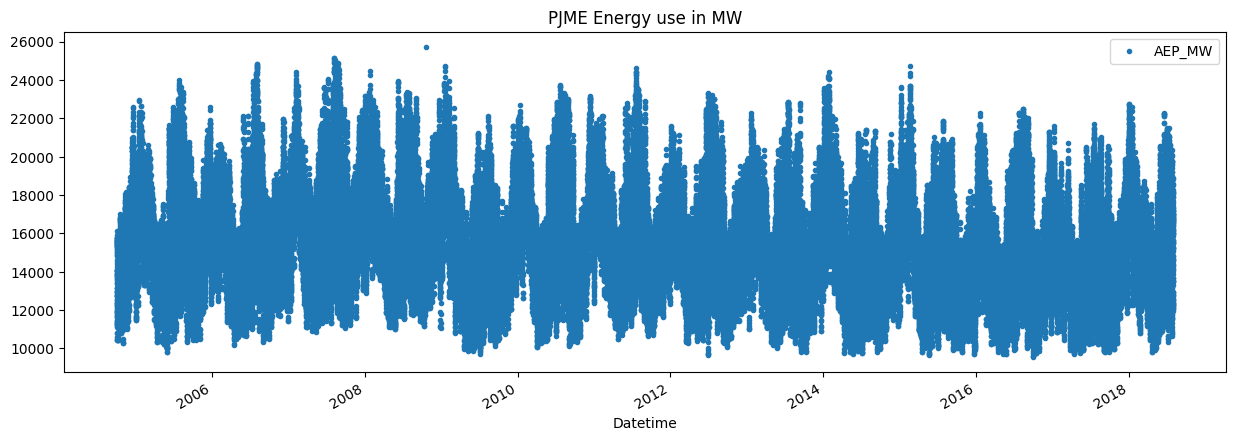

In [7]:
df_untouched.plot(style='.', figsize=(15,5), color=color_pal[0], title='PJME Energy use in MW')

# 1. Train test split & some vizz

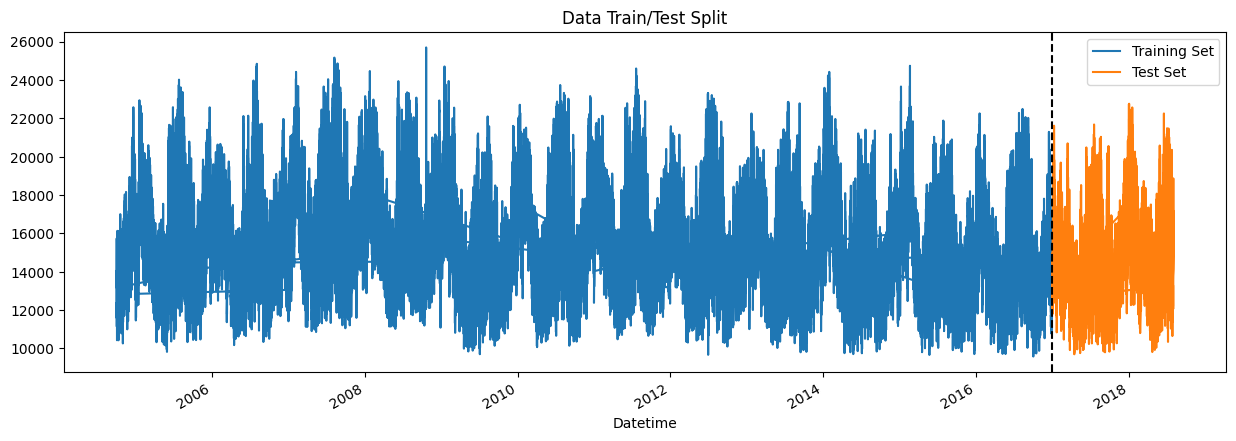

In [8]:
train_full = df_untouched.loc[df_untouched.index < '01-01-2017']
test_full = df_untouched.loc[df_untouched.index >= '01-01-2017']

fig, ax = plt.subplots(figsize=(15, 5))
train_full.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test_full.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2017', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

In [9]:
train_full.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


In [10]:
week = df_untouched.loc[(df_untouched.index > '01-01-2010') & (df_untouched.index < '01-08-2010')]
week.head()

,AEP_MW
Datetime,
2010-01-07 01:00:00,18483.0
2010-01-07 02:00:00,18088.0
2010-01-07 03:00:00,17984.0
2010-01-07 04:00:00,17978.0
2010-01-07 05:00:00,18300.0


In [11]:
moment = df_untouched.loc[(df_untouched.index == '2010-01-07 01:00:00')]
moment.head()

,AEP_MW
Datetime,
2010-01-07 01:00:00,18483.0


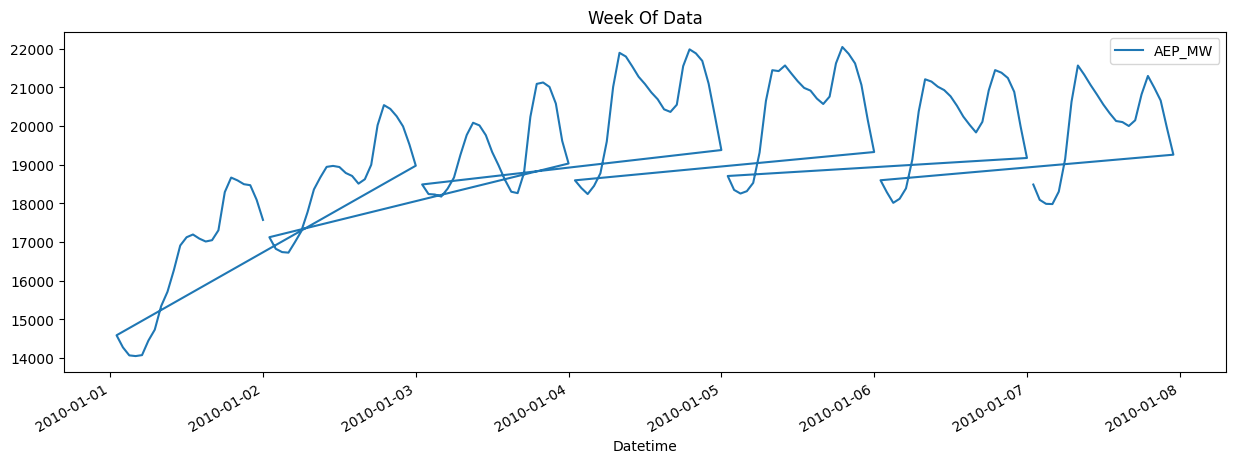

In [12]:
df_untouched.loc[(df_untouched.index > '01-01-2010') & (df_untouched.index < '01-08-2010')].plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# 2. Feature Engineering/ creation

In [23]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy().drop(columns=['AEP_MW'])
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

In [24]:
df_features = create_features(df_untouched)
df_features.head()

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,
2004-12-31 01:00:00,1,4,4,12,2004,366,31,53
2004-12-31 02:00:00,2,4,4,12,2004,366,31,53
2004-12-31 03:00:00,3,4,4,12,2004,366,31,53
2004-12-31 04:00:00,4,4,4,12,2004,366,31,53
2004-12-31 05:00:00,5,4,4,12,2004,366,31,53


In [25]:
df_untouched.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


## Run datasets through **create_features** function

In [26]:
df_features.columns

Index(['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')

In [27]:
features = ['hour', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear', 'dayofmonth', 'weekofyear']
target = 'AEP_MW'

## Visualization

Template:

Feature can be day, hour, year, quarter, etc.

```
fig , ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='<feature>', y='AEP_MW', ax=ax)
ax.set_title('MW by <feature> of day')
plt.show()
```



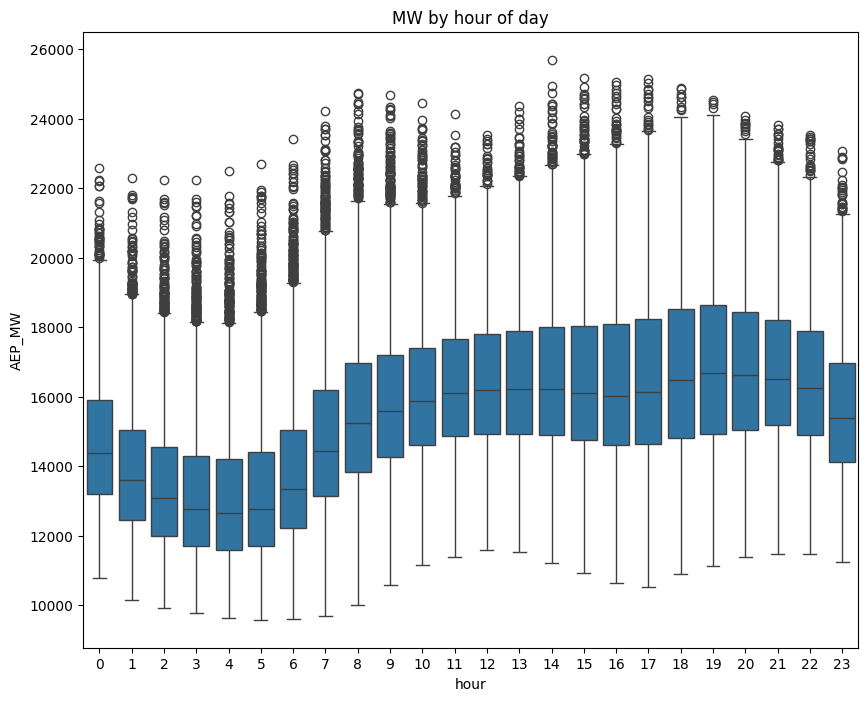

In [28]:
fig , ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df, x='hour', y='AEP_MW', ax=ax)
ax.set_title('MW by hour of day')
plt.show()

## 3. Create model

In [31]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)

## 4. Cross-validation: **time-series split** & train/ evaluate

Since this is time-series data, and to ensure proper generalization, we will apply time-series cross val.


In [28]:
# imports
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [29]:
tscv = TimeSeriesSplit(n_splits=5)

In [30]:
display(train_full.columns)
display(train_full.index)

Index(['AEP_MW'], dtype='object')

DatetimeIndex(['2004-12-31 01:00:00', '2004-12-31 02:00:00',
               '2004-12-31 03:00:00', '2004-12-31 04:00:00',
               '2004-12-31 05:00:00', '2004-12-31 06:00:00',
               '2004-12-31 07:00:00', '2004-12-31 08:00:00',
               '2004-12-31 09:00:00', '2004-12-31 10:00:00',
               ...
               '2016-01-01 15:00:00', '2016-01-01 16:00:00',
               '2016-01-01 17:00:00', '2016-01-01 18:00:00',
               '2016-01-01 19:00:00', '2016-01-01 20:00:00',
               '2016-01-01 21:00:00', '2016-01-01 22:00:00',
               '2016-01-01 23:00:00', '2016-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=107377, freq=None)

In [32]:
# creation of train/val sets is sourced from train data, test remains untouched

for train_idx, val_idx in tscv.split(train_full):
    # create folds
    train_full_fold = train_full.iloc[train_idx]
    val_full_fold = train_full.iloc[val_idx]

    # grab targets
    y_train = train_full_fold["AEP_MW"]
    y_val = val_full_fold["AEP_MW"]

    # create features on predictors ONLY
    x_train_features_fold = create_features(train_full_fold)
    x_val_features_fold = create_features(val_full_fold)

    # fit to model & evaluate
    reg.fit(x_train_features_fold, y_train,
            eval_set=[(x_val_features_fold, y_val)],
            verbose=100
            )

[0]	validation_0-rmse:16475.39485


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:43:26] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:6723.51207
[200]	validation_0-rmse:3268.99898
[300]	validation_0-rmse:2145.11815
[400]	validation_0-rmse:1799.08744
[500]	validation_0-rmse:1688.43399
[600]	validation_0-rmse:1646.02429
[700]	validation_0-rmse:1634.70829
[800]	validation_0-rmse:1628.70678
[900]	validation_0-rmse:1626.31441
[993]	validation_0-rmse:1626.47106
[0]	validation_0-rmse:15775.93259


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:43:28] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:5807.09899
[200]	validation_0-rmse:2473.86768
[300]	validation_0-rmse:1779.03140
[391]	validation_0-rmse:1761.74350
[0]	validation_0-rmse:15723.70666


...

[100]	validation_0-rmse:5812.20713
[200]	validation_0-rmse:2515.07094
[300]	validation_0-rmse:1691.77685
[400]	validation_0-rmse:1545.99425
[500]	validation_0-rmse:1537.98493
[515]	validation_0-rmse:1538.43652
[0]	validation_0-rmse:15252.40522


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:43:31] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:5384.72977
[200]	validation_0-rmse:2199.98936
[300]	validation_0-rmse:1571.08028
[400]	validation_0-rmse:1530.65865
[411]	validation_0-rmse:1532.44881
[0]	validation_0-rmse:14952.32078


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [10:43:33] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:5250.38240
[200]	validation_0-rmse:2235.60714
[300]	validation_0-rmse:1691.87561
[400]	validation_0-rmse:1643.91539
[500]	validation_0-rmse:1632.27435
[600]	validation_0-rmse:1624.83266
[688]	validation_0-rmse:1622.20285


## 5. Feature importance & viz

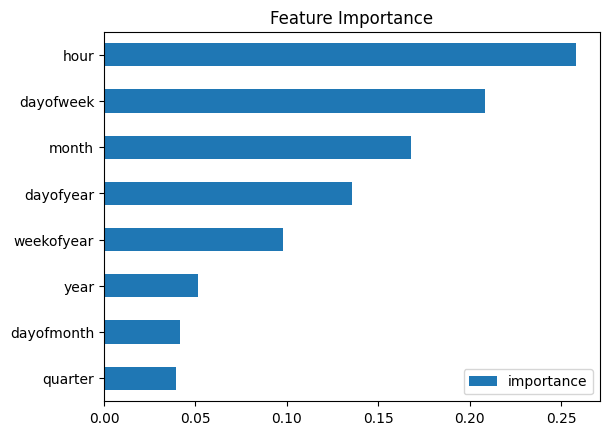

In [33]:
feat_imp = pd.DataFrame(data= reg.feature_importances_,
                        index=reg.feature_names_in_,
                        columns=['importance'])
feat_imp.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

## 6. Forecasting on Test data

Must call create_features() first, so model gets the same columns it was trained on ☺

In [44]:
# create features on test
x_test_features = create_features(test_full)
y_test = test_full["AEP_MW"]
x_test_features_full = pd.concat([x_test_features, y_test], axis=1)

y_pred = reg.predict(x_test_features)
x_test_features_full['prediction'] = y_pred

In [52]:
x_test_features_full.head()

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,AEP_MW,prediction
Datetime,,,,,,,,,,
2017-01-01 00:00:00,0,6,1,1,2017,1,1,52,13240.0,15011.881836
2017-12-31 01:00:00,1,6,4,12,2017,365,31,52,17422.0,13903.676758
2017-12-31 02:00:00,2,6,4,12,2017,365,31,52,17219.0,13512.021484
2017-12-31 03:00:00,3,6,4,12,2017,365,31,52,17313.0,13446.827148
2017-12-31 04:00:00,4,6,4,12,2017,365,31,52,17396.0,13446.827148


## 7. Scoring

In [53]:
score = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 1752.73


In [54]:
print(y_test.describe())

count    13896.000000
mean     14781.961356
std       2404.047783
min       9698.000000
25%      13070.750000
50%      14503.000000
75%      16256.000000
max      22759.000000
Name: AEP_MW, dtype: float64


In [55]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAPE: {mape*100:.2f}%')

MAPE: 9.80%
